# 09 - Statistical Testing, Efficiency and Final Report

Closes the study:

1. **Demsar framework** - Friedman test with Iman-Davenport correction, post-hoc Nemenyi,
   and a critical-difference diagram, run separately on each dataset.
2. **1D-CNN baseline** - the DAS_CNN reference architecture trained on the *same*
   leakage-safe splits, so the comparison is like-for-like.
3. **Computational efficiency** - offline feature preparation vs online inference,
   against the real-time window-arrival budget.
4. **Report export** - every table and figure the manuscript needs, written to
   `Results/shared/`.

In [1]:
import sys, json, time
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, fusion as F, evaluate as EV, models as MD

sns.set_theme(style="whitegrid", context="notebook")

SMOKE_TEST = False
VARIANT    = "full_1002"      # "full_1002" | "8_consensus" | "" for a flat layout
suffix = "_smoke" if SMOKE_TEST else ""
DATASETS = ("cao", "tomasov")

def stage_dir(ds, stage):
    # Stage directory, honouring the per-feature-set sub-folder if present.
    # Notebooks 06 and 07 are run once per feature set, so their outputs live
    # in `<stage>/<VARIANT>/`. Fall back to the flat directory when no variant
    # sub-folder exists, so an un-split layout still works.
    base = C.results_dir(ds, stage + suffix)
    cand = base / VARIANT if VARIANT else base
    return cand if cand.exists() else base

tag = f"_{VARIANT}" if VARIANT else ""
report_dir = C.results_dir("shared", f"09_report{suffix}{tag}", "tables")
fig_dir    = C.results_dir("shared", f"09_report{suffix}{tag}", "figures")
print("variant   :", VARIANT or "(flat)")
print("reading   :", stage_dir(DATASETS[0], "06_benchmark"))
print("writing   :", report_dir.parent)

variant   : full_1002
reading   : /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/cao/06_benchmark/full_1002
writing   : /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/shared/09_report_full_1002


## 1. Demsar (2006) multi-classifier comparison

The benchmark grid from notebook 06 is the input: rows are balancing strategies
(conditions), columns are classifiers. The Friedman test asks whether any classifier
differs; Nemenyi says which pairs.

In [2]:
stats = {}
for ds in DATASETS:
    path = stage_dir(ds, "06_benchmark") / "benchmark_full.csv"
    if not path.exists():
        print(f"skip {ds}: run notebook 06 first"); continue
    b = pd.read_csv(path)
    pivot = b.pivot(index="strategy", columns="model", values="test_f1_macro").dropna(axis=1)
    st = EV.friedman_nemenyi(pivot)
    stats[ds] = st

    print(f"\n=== {ds} ===")
    print(f"conditions (strategies) n = {st['n_conditions']}, classifiers k = {st['n_models']}")
    print(f"Friedman chi2 = {st['friedman_chi2']:.2f}  p = {st['friedman_p']:.3e}")
    print(f"Iman-Davenport F = {st['iman_davenport_F']:.2f} "
          f"(df1={st['df1']}, df2={st['df2']})")
    print(f"Nemenyi critical difference (alpha=0.05) = {st['critical_difference']:.3f}")
    display(st["ranking"].round(3))
    print("groups not significantly different:")
    for g in EV.cd_groups(st["ranking"], st["critical_difference"]):
        print("   ", " = ".join(g))


=== cao ===
conditions (strategies) n = 6, classifiers k = 7
Friedman chi2 = 35.43  p = 3.559e-06
Iman-Davenport F = 310.00 (df1=6, df2=30)
Nemenyi critical difference (alpha=0.05) = 3.677


,model,avg_rank
0,LightGBM,1.000
1,HistGradientBoosting,2.333
2,XGBoost,2.667
3,LogisticRegression,4.000
4,RandomForest,5.000
5,ExtraTrees,6.000
6,DecisionTree,7.000


groups not significantly different:
    LightGBM = HistGradientBoosting = XGBoost = LogisticRegression
    LightGBM = HistGradientBoosting = XGBoost = LogisticRegression = RandomForest = ExtraTrees
    LightGBM = HistGradientBoosting = XGBoost = LogisticRegression = RandomForest = ExtraTrees = DecisionTree
    HistGradientBoosting = XGBoost = LogisticRegression = RandomForest = ExtraTrees = DecisionTree
    LogisticRegression = RandomForest = ExtraTrees = DecisionTree

=== tomasov ===
conditions (strategies) n = 6, classifiers k = 7
Friedman chi2 = 35.36  p = 3.674e-06
Iman-Davenport F = 275.00 (df1=6, df2=30)
Nemenyi critical difference (alpha=0.05) = 3.677


,model,avg_rank
0,HistGradientBoosting,1.5
1,LightGBM,1.5
2,XGBoost,3.0
3,LogisticRegression,4.0
4,RandomForest,5.0
5,DecisionTree,6.0
6,ExtraTrees,7.0


groups not significantly different:
    HistGradientBoosting = LightGBM = XGBoost = LogisticRegression = RandomForest
    HistGradientBoosting = LightGBM = XGBoost = LogisticRegression = RandomForest = DecisionTree
    HistGradientBoosting = LightGBM = XGBoost = LogisticRegression = RandomForest = DecisionTree = ExtraTrees
    XGBoost = LogisticRegression = RandomForest = DecisionTree = ExtraTrees
    LogisticRegression = RandomForest = DecisionTree = ExtraTrees


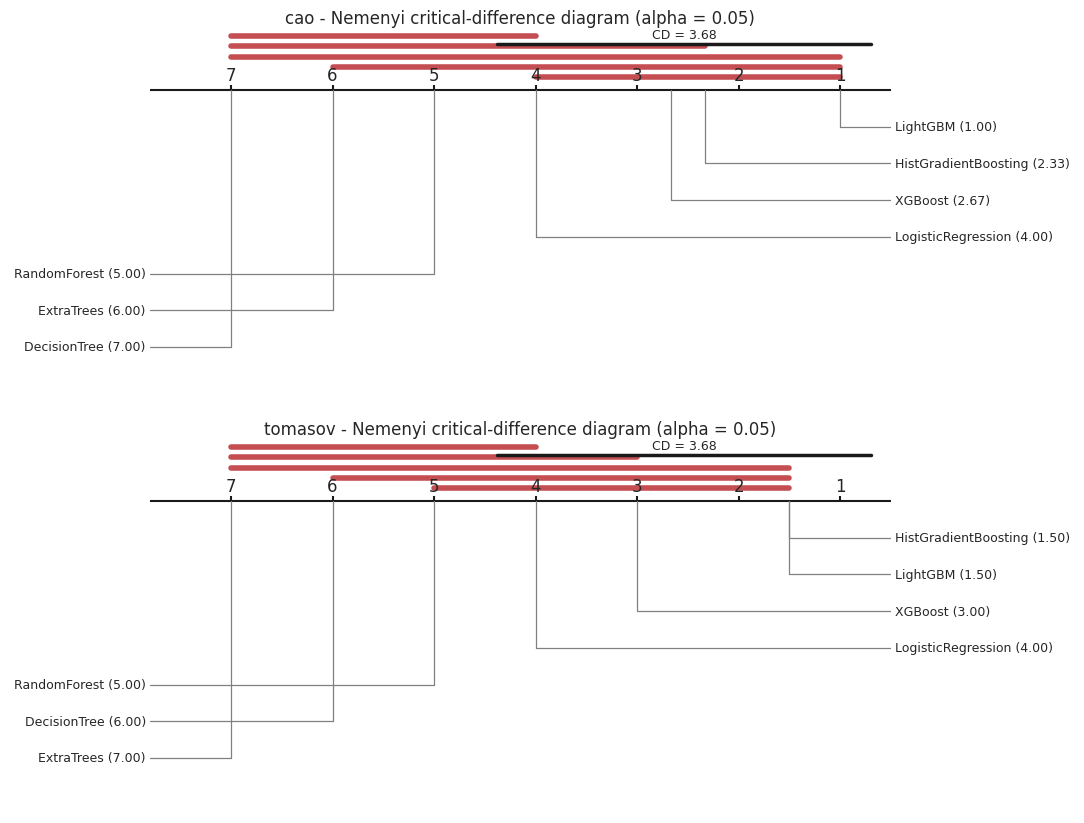

,dataset,friedman_chi2,friedman_p,iman_davenport_F,critical_difference,best_model,best_avg_rank
0,cao,35.429,0.000004,310.0,3.677,LightGBM,1.0
1,tomasov,35.357,0.000004,275.0,3.677,HistGradientBoosting,1.5


In [3]:
def cd_diagram(st, ax, title):
    r = st["ranking"]; cd = st["critical_difference"]
    lo, hi = 0.5, r.avg_rank.max() + 0.8
    ax.set_xlim(hi, lo); ax.set_ylim(-len(r) - 1.5, 1.6)
    ax.hlines(0, lo, hi, color="k")
    for t in np.arange(np.ceil(lo), np.floor(hi) + 1):
        ax.vlines(t, 0, 0.13, color="k"); ax.text(t, 0.28, f"{int(t)}", ha="center")
    for i, row in r.iterrows():
        y = -i - 1
        ax.plot([row.avg_rank, row.avg_rank], [0, y], color="grey", lw=0.9)
        ax.plot([row.avg_rank, lo if i < len(r)/2 else hi], [y, y], color="grey", lw=0.9)
        ax.text(lo if i < len(r)/2 else hi, y,
                f" {row.model} ({row.avg_rank:.2f}) ",
                ha="left" if i < len(r)/2 else "right", va="center", fontsize=9)
    # cliques
    lvl = 0.35
    for g in EV.cd_groups(r, cd):
        if len(g) < 2: continue
        sub = r[r.model.isin(g)]
        ax.plot([sub.avg_rank.min(), sub.avg_rank.max()], [lvl, lvl], lw=4, color="#C44E52")
        lvl += 0.28
    ax.plot([lo + 0.2, lo + 0.2 + cd], [1.25, 1.25], lw=2.5, color="k")
    ax.text(lo + 0.2 + cd/2, 1.42, f"CD = {cd:.2f}", ha="center", fontsize=9)
    ax.set_title(title); ax.axis("off")

if stats:
    fig, axes = plt.subplots(len(stats), 1, figsize=(11, 4.2*len(stats)))
    axes = np.atleast_1d(axes)
    for ax, (ds, st) in zip(axes, stats.items()):
        cd_diagram(st, ax, f"{ds} - Nemenyi critical-difference diagram (alpha = 0.05)")
    plt.tight_layout()
    plt.savefig(fig_dir / "critical_difference.png", dpi=200, bbox_inches="tight")
    plt.show()

    rows = []
    for ds, st in stats.items():
        rows.append({"dataset": ds, "friedman_chi2": round(st["friedman_chi2"], 3),
                     "friedman_p": st["friedman_p"],
                     "iman_davenport_F": round(st["iman_davenport_F"], 3),
                     "critical_difference": round(st["critical_difference"], 3),
                     "best_model": st["ranking"].model.iloc[0],
                     "best_avg_rank": round(st["ranking"].avg_rank.iloc[0], 3)})
    stat_table = pd.DataFrame(rows)
    display(stat_table)
    stat_table.to_csv(report_dir / "statistical_tests.csv", index=False)

## 2. 1D-CNN baseline on the same splits

The submitted version compared against a CNN trained under a different protocol. Here the
DAS_CNN architecture is trained on the **identical leakage-safe splits**, so any gap is
attributable to the model rather than to the evaluation.

The CNN consumes the raw window; the feature pipeline consumes the engineered vector.
Both see exactly the same windows.

In [4]:
# ---------------------------- CONFIGURE ME ----------------------------
RUN_CNN   = True        # set True to train the baseline
EPOCHS    = 20
BATCH     = 256
# Windows loaded PER CLASS PER SPLIT.  Keep this modest: the loader holds every
# window in RAM at once, and on a Jetson the CPU and GPU share the same pool.
CNN_PER_CLASS = {"train": 1500, "val": 400, "test": 400}
MAX_GB    = 4.0          # abort rather than start a run that will not fit
# -----------------------------------------------------------------------

# WHY THIS CELL WAS REWRITTEN
# The first version hung the machine, for four compounding reasons:
#   1. `Xs.append(x[::4][:2048])` appends a *view*.  numpy keeps the parent
#      buffer alive, so each row retained the whole preprocessed patch
#      (2.10 MB for Tomasov, 0.79 MB for Cao) instead of the 8 kB actually
#      needed - 226 GB and 57 GB respectively at 4000 rows per class/split.
#      Fixed with np.ascontiguousarray(..., dtype=np.float32) into a
#      preallocated array.
#   2. `with pp.TomasovReader(r.h5_path)` inside the row loop reopened a
#      multi-GB HDF5 file once per window.  Fixed by sorting on the recording
#      and holding one reader open per file.
#   3. It read all 32 channels of the patch and then used one.  The CNN is
#      single-channel, so we now read one locus and call `preprocess_1d`.
#   4. Inference ran the entire test split through a 33 M-parameter network in
#      a single forward pass.  Now batched.

if not RUN_CNN:
    print("RUN_CNN = False - skipping the CNN baseline.")
    print("Set RUN_CNN = True to train it; check the printed memory estimate first.")
else:
    import gc
    import torch, torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    from dasfe import preprocess as pp

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"device: {dev}")
    if dev == "cuda":
        print(f"  {torch.cuda.get_device_name(0)}")

    CNN_LEN, DECIM = 2048, 4          # 8192 samples -> every 4th -> 2048

    def load_windows(ds):
        # Return (X float32 [n, CNN_LEN], y labels, split tags), memory-safe.
        spec = C.DATASETS[ds]
        mani = pd.read_parquet(C.results_dir(ds, "01_splits") / "split_manifest.parquet")

        parts = []
        for (label, sp), g in mani.groupby(["label", "split"]):
            n = min(CNN_PER_CLASS.get(sp, 0), len(g))
            if n:
                parts.append(g.sample(n, random_state=C.SEED))
        sub = pd.concat(parts).reset_index(drop=True)

        gb = len(sub) * CNN_LEN * 4 / 1e9
        print(f"  {ds}: {len(sub):,} windows -> {gb:.2f} GB as float32")
        if gb > MAX_GB:
            raise MemoryError(
                f"{gb:.2f} GB exceeds MAX_GB={MAX_GB}. Lower CNN_PER_CLASS."
            )

        # Sort by recording so each HDF5 file is opened exactly once.
        sort_col = "h5_path" if ds == "tomasov" else "path"
        sub = sub.sort_values(sort_col).reset_index(drop=True)

        X = np.empty((len(sub), CNN_LEN), dtype=np.float32)
        y = sub["label"].to_numpy()
        sp = sub["split"].to_numpy()

        if ds == "cao":
            for i, r in enumerate(sub.itertuples()):
                raw = pp.load_cao_window(r.path, spec.win_len)
                ref = pp.cao_reference_channel(raw)
                x = pp.preprocess_1d(raw[ref], spec.fs)
                X[i] = np.ascontiguousarray(x[::DECIM][:CNN_LEN], dtype=np.float32)
                if (i + 1) % 2000 == 0:
                    print(f"    {i+1:,}/{len(sub):,}", flush=True)
        else:
            reader, cur = None, None
            try:
                for i, r in enumerate(sub.itertuples()):
                    if r.h5_path != cur:                 # one open per recording
                        if reader is not None:
                            reader.close()
                        reader = pp.TomasovReader(r.h5_path)
                        cur = r.h5_path
                        print(f"    opened {Path(cur).name}", flush=True)
                    # Read ONE locus, not the full 32-channel patch.
                    trace = reader.read_patch(int(r.t0), int(r.locus), spec.win_len, 1)[0]
                    x = pp.preprocess_1d(trace, reader.fs)
                    X[i] = np.ascontiguousarray(x[::DECIM][:CNN_LEN], dtype=np.float32)
                    if (i + 1) % 2000 == 0:
                        print(f"    {i+1:,}/{len(sub):,}", flush=True)
            finally:
                if reader is not None:
                    reader.close()
        return X, y, sp

    @torch.no_grad()
    def predict_batched(net, X, batch=512):
        net.eval()
        out = []
        for i in range(0, len(X), batch):
            xb = torch.from_numpy(X[i:i+batch]).unsqueeze(1).to(dev)
            out.append(net(xb).argmax(1).cpu().numpy())
        return np.concatenate(out)

    cnn_rows = []
    for ds in DATASETS:
        t_load = time.perf_counter()
        X, y, sp = load_windows(ds)
        print(f"  loaded in {time.perf_counter()-t_load:.0f}s "
              f"({X.nbytes/1e9:.2f} GB resident)")

        classes = sorted(set(y))
        yi = np.array([classes.index(v) for v in y])
        tr, te = sp == "train", sp == "test"

        net = MD.build_cnn_baseline(len(classes), CNN_LEN).to(dev)
        n_par = sum(p.numel() for p in net.parameters())
        print(f"  {n_par:,} parameters ({n_par*4/1e6:.1f} MB fp32)")

        w = torch.tensor(1.0 / np.bincount(yi[tr], minlength=len(classes)),
                         dtype=torch.float32, device=dev)
        w = w / w.mean()
        opt = torch.optim.Adam(net.parameters(), lr=1e-4)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3)
        lossf = nn.CrossEntropyLoss(weight=w)

        dl = DataLoader(
            TensorDataset(torch.from_numpy(X[tr]).unsqueeze(1),
                          torch.from_numpy(yi[tr])),
            batch_size=BATCH, shuffle=True, num_workers=0,
        )
        t0 = time.perf_counter()
        for ep in range(EPOCHS):
            net.train(); tot = 0.0
            for xb, yb in dl:
                xb, yb = xb.to(dev, non_blocking=True), yb.to(dev, non_blocking=True)
                opt.zero_grad(); l = lossf(net(xb), yb); l.backward(); opt.step()
                tot += float(l) * len(xb)
            sched.step(tot / max(tr.sum(), 1))
            if (ep + 1) % 5 == 0:
                print(f"  {ds} epoch {ep+1}/{EPOCHS} loss {tot/max(tr.sum(),1):.4f}", flush=True)
        train_s = time.perf_counter() - t0

        pred = predict_batched(net, X[te])
        met = EV.score_all(yi[te], pred)
        cnn_rows.append({
            "dataset": ds, "model": "1D-CNN (DAS_CNN)",
            "n_train": int(tr.sum()), "n_test": int(te.sum()),
            "accuracy": 100*met["accuracy"],
            "balanced_accuracy": 100*met["balanced_accuracy"],
            "f1_macro": 100*met["f1_macro"],
            "train_seconds": round(train_s, 1), "n_params": n_par,
        })
        print(f"{ds}: CNN accuracy {100*met['accuracy']:.2f}%  "
              f"macro-F1 {100*met['f1_macro']:.2f}%  ({train_s:.0f}s)\n")

        del X, net, dl, opt
        gc.collect()
        if dev == "cuda":
            torch.cuda.empty_cache()

    cnn = pd.DataFrame(cnn_rows)
    display(cnn.round(2))
    cnn.to_csv(report_dir / "cnn_baseline.csv", index=False)

device: cuda
  Orin
  cao: 12,034 windows -> 0.10 GB as float32
    2,000/12,034
    4,000/12,034
    6,000/12,034
    8,000/12,034
    10,000/12,034
    12,000/12,034
  loaded in 43s (0.10 GB resident)
  33,152,774 parameters (132.6 MB fp32)


/tmp/ipykernel_5795/1099772895.py:141: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  tot += float(l) * len(xb)


  cao epoch 5/20 loss 0.6540
  cao epoch 10/20 loss 0.4167
  cao epoch 15/20 loss 0.2888
  cao epoch 20/20 loss 0.2037
cao: CNN accuracy 81.85%  macro-F1 79.25%  (64s)

  tomasov: 20,434 windows -> 0.17 GB as float32
    opened auto2_2023-04-17T124510+0100.h5
    opened auto4_2023-06-06T144655+0100.h5
    opened auto4_2023-06-06T145055+0100.h5
    opened auto_2023-04-17T124152+0100.h5
    2,000/20,434
    opened reconstruction1_2023-06-06T150714+0100.h5
    4,000/20,434
    opened fence_2023-04-17T123117+0100.h5
    opened kopani_plot_2023-11-07T150207Z.h5
    6,000/20,434
    opened plot_2023-11-07T150119Z.h5
    opened longboard_2023-04-17T123543+0100.h5
    8,000/20,434
    opened longboardroad_2023-04-17T123638+0100.h5
    opened manipulation_2023-04-17T122847+0100.h5
    10,000/20,434
    opened openingclosing_2023-04-17T122658+0100.h5
    12,000/20,434
    opened regularshit_2023-04-17T130103+0100.h5
    14,000/20,434
    opened running_2023-04-17T122413+0100.h5
    16,000/20,434

,dataset,model,n_train,n_test,accuracy,balanced_accuracy,f1_macro,train_seconds,n_params
0,cao,1D-CNN (DAS_CNN),9000,1581,81.85,80.87,79.25,64.1,33152774
1,tomasov,1D-CNN (DAS_CNN),13500,3398,57.18,55.02,54.46,91.9,33155849


## 3. Computational efficiency

Two phases with very different economics: feature preparation is a one-time offline cost;
inference is the per-window cost that has to fit the real-time budget.

In [5]:
eff_rows = []
for ds in DATASETS:
    tpath = C.results_dir(ds, "03_features" + suffix) / "extraction_timing.json"
    cpath = stage_dir(ds, "07_final") / "model_card.json"
    if not tpath.exists():
        continue
    t = json.loads(tpath.read_text())
    spec = C.DATASETS[ds]
    for dom, ms in t["per_domain_ms_per_window"].items():
        eff_rows.append({"dataset": ds, "phase": "offline feature extraction",
                         "stage": dom, "ms_per_window": round(ms, 3),
                         "hours_for_100k_windows": round(ms*100_000/1000/3600, 3)})
    fpath = C.results_dir(ds, "05_selection" + suffix) / "fs_timings_multi.json"
    if fpath.exists():
        for meth, secs in json.loads(fpath.read_text()).items():
            eff_rows.append({"dataset": ds, "phase": "offline feature selection",
                             "stage": meth, "ms_per_window": np.nan,
                             "hours_for_100k_windows": round(secs/3600, 4)})
    if cpath.exists():
        card = json.loads(cpath.read_text())
        eff_rows.append({"dataset": ds, "phase": "online inference",
                         "stage": f"{card['model']} predict",
                         "ms_per_window": round(card["inference_ms_per_sample"], 5),
                         "hours_for_100k_windows":
                             round(card["inference_ms_per_sample"]*100_000/1000/3600, 5)})

eff = pd.DataFrame(eff_rows)
display(eff)
eff.to_csv(report_dir / "computational_efficiency.csv", index=False)

,dataset,phase,stage,ms_per_window,hours_for_100k_windows
0,cao,offline feature extraction,time,42.61900,1.18400
1,cao,offline feature extraction,freq,3.33900,0.09300
2,cao,offline feature extraction,tf,59.48700,1.65200
3,cao,offline feature extraction,spatial,17.09700,0.47500
4,cao,offline feature extraction,TOTAL,122.54200,3.40400
5,cao,offline feature selection,variance,NaN,0.00000
6,cao,offline feature selection,pearson,NaN,0.00010
7,cao,offline feature selection,mutual_info,NaN,0.01410
8,cao,offline feature selection,relieff,NaN,0.06010
9,cao,offline feature selection,mrmr,NaN,0.04030


In [6]:
# Real-time budget: a new window arrives every WIN_HOP / fs seconds.
budget_rows = []
for ds in DATASETS:
    spec = C.DATASETS[ds]
    arrival_ms = 1000 * C.WIN_HOP / spec.fs
    sub = eff[(eff.dataset == ds) & (eff.phase == "offline feature extraction")]
    extract_ms = sub.loc[sub.stage == "TOTAL", "ms_per_window"]
    sub = eff[eff.dataset == ds]
    infer_ms = sub.loc[sub.phase == "online inference", "ms_per_window"]
    if not len(extract_ms):
        continue
    e = float(extract_ms.iloc[0])
    i = float(infer_ms.iloc[0]) if len(infer_ms) else 0.0
    total = e + i
    budget_rows.append({
        "dataset": ds,
        "window arrival interval (ms)": round(arrival_ms, 2),
        "feature extraction (ms)": round(e, 2),
        "inference (ms)": round(i, 4),
        "total (ms)": round(total, 2),
        "real-time on 1 core": "yes" if total < arrival_ms else "no",
        "cores needed": int(np.ceil(total / arrival_ms)),
    })
budget = pd.DataFrame(budget_rows)
display(budget)
budget.to_csv(report_dir / "realtime_budget.csv", index=False)

print("\nThe honest framing: inference is sub-millisecond and comfortably real-time,")
print("but the *feature extraction* stage is the binding constraint. Meeting the budget")
print("on one channel requires the core count above, or GPU/parallel pre-computation.")

,dataset,window arrival interval (ms),feature extraction (ms),inference (ms),total (ms),real-time on 1 core,cores needed
0,cao,204.8,122.54,0.0624,122.60,yes,1
1,tomasov,102.4,144.59,0.1716,144.77,no,2



The honest framing: inference is sub-millisecond and comfortably real-time,
but the *feature extraction* stage is the binding constraint. Meeting the budget
on one channel requires the core count above, or GPU/parallel pre-computation.


## 4. Head-to-head results table for the manuscript

In [7]:
main_rows = []
for ds in DATASETS:
    cpath = stage_dir(ds, "07_final") / "model_card.json"
    bpath = stage_dir(ds, "06_benchmark") / "best_config.json"
    if not cpath.exists():
        continue
    card = json.loads(cpath.read_text())
    bench = json.loads(bpath.read_text()) if bpath.exists() else {}
    main_rows.append({
        "Dataset": {"cao": "Cao et al. 2023", "tomasov": "Tomasov et al. 2025"}[ds],
        "Classes": card["n_classes"],
        "Split protocol": {"cao": "session-grouped",
                           "tomasov": "blocked segment + guard band"}[ds],
        "Feature set": VARIANT or "flat",
        "Features": card["n_features"],
        "Model": card["model"],
        "Balancing": card["balancing"],
        "Accuracy (%)": card["test"]["accuracy"],
        "Balanced acc. (%)": card["test"]["balanced_accuracy"],
        "Macro-F1 (%)": card["test"]["f1_macro"],
        "CV macro-F1 (%)": round(100*bench.get("cv_f1_macro_mean", np.nan), 2)
                           if bench.get("cv_f1_macro_mean") else np.nan,
        "Inference (ms/sample)": card["inference_ms_per_sample"],
    })
main = pd.DataFrame(main_rows)
display(main)
main.to_csv(report_dir / "main_results.csv", index=False)

,Dataset,Classes,Split protocol,Feature set,Features,Model,Balancing,Accuracy (%),Balanced acc. (%),Macro-F1 (%),CV macro-F1 (%),Inference (ms/sample)
0,Cao et al. 2023,6,session-grouped,full_1002,1002,LightGBM,undersample,99.057,98.980,98.897,98.51,0.06238
1,Tomasov et al. 2025,9,blocked segment + guard band,full_1002,1002,LightGBM,borderline_smote,90.709,81.972,81.978,78.60,0.17157


## 5. Protocol-comparison table

The table that answers the reviewers directly: what changed, and what it cost.

In [8]:
protocol = pd.DataFrame([
    {"Aspect": "Datasets", "Submitted": "1 (Tomasov)", "Revised": "2 (Tomasov + Cao)"},
    {"Aspect": "Split", "Submitted": "random stratified 80/10/10",
     "Revised": "group-aware: session (Cao) / blocked segment + guard band (Tomasov)"},
    {"Aspect": "Test windows sharing raw samples with train",
     "Submitted": "100%", "Revised": "0% (verified programmatically)"},
    {"Aspect": "Cao official split", "Submitted": "n/a",
     "Revised": "rejected - 423/441 sessions span train and test"},
    {"Aspect": "Feature selection", "Submitted": "fitted once on the full training set",
     "Revised": "re-fitted inside every CV fold; optimism quantified"},
    {"Aspect": "Resampling", "Submitted": "applied to the training set",
     "Revised": "inside an imblearn Pipeline, per fold"},
    {"Aspect": "Scaling", "Submitted": "not stated",
     "Revised": "StandardScaler inside the pipeline, training folds only"},
    {"Aspect": "Feature extraction cost", "Submitted": "4 separate passes (~23 h total)",
     "Revised": "1 pass, all 4 domains, chunked and resumable"},
    {"Aspect": "External validity", "Submitted": "argued Cao was unusable",
     "Revised": "parallel benchmark + harmonised 4-class cross-system transfer"},
    {"Aspect": "Class ablation framing", "Submitted": "reported as improved performance",
     "Revised": "reported as class-difficulty accounting; full taxonomy is the headline"},
])
display(protocol)
protocol.to_csv(report_dir / "protocol_comparison.csv", index=False)

,Aspect,Submitted,Revised
0,Datasets,1 (Tomasov),2 (Tomasov + Cao)
1,Split,random stratified 80/10/10,group-aware: session (Cao) / blocked segment +...
2,Test windows sharing raw samples with train,100%,0% (verified programmatically)
3,Cao official split,n/a,rejected - 423/441 sessions span train and test
4,Feature selection,fitted once on the full training set,re-fitted inside every CV fold; optimism quant...
5,Resampling,applied to the training set,"inside an imblearn Pipeline, per fold"
6,Scaling,not stated,"StandardScaler inside the pipeline, training f..."
7,Feature extraction cost,4 separate passes (~23 h total),"1 pass, all 4 domains, chunked and resumable"
8,External validity,argued Cao was unusable,parallel benchmark + harmonised 4-class cross-...
9,Class ablation framing,reported as improved performance,reported as class-difficulty accounting; full ...


## 6. Manifest of everything produced

In [9]:
artefacts = []
for p in sorted(C.RESULTS_DIR.rglob("*")):
    if p.is_file():
        artefacts.append({"path": str(p.relative_to(C.RESULTS_DIR)),
                          "kind": p.suffix.lstrip("."),
                          "MB": round(p.stat().st_size/1e6, 3)})
arte = pd.DataFrame(artefacts)
print(f"{len(arte)} artefacts, {arte.MB.sum():.1f} MB total\n")
display(arte.groupby("kind").agg(files=("path","size"), MB=("MB","sum")).round(2))
arte.to_csv(report_dir / "artefact_manifest.csv", index=False)

print("\nFigures ready for the manuscript:")
for p in sorted(C.RESULTS_DIR.rglob("*.png")):
    print("  ", p.relative_to(C.RESULTS_DIR))

646 artefacts, 2358.0 MB total



,files,MB
kind,,
csv,147,1.28
json,50,0.18
npy,359,2337.55
npz,4,0.04
parquet,8,5.99
png,78,12.92



Figures ready for the manuscript:
   cao/00_inventory/class_and_session_counts.png
   cao/01_splits/split_by_date.png
   cao/03_features/class_feature_profile.png
   cao/03_features/example_window_water.png
   cao/03_features_smoke/class_feature_profile.png
   cao/03_features_smoke/example_window_shake.png
   cao/04_fusion/feature_scales_and_redundancy.png
   cao/04_fusion_smoke/feature_scales_and_redundancy.png
   cao/05_selection/consensus_votes_and_domains.png
   cao/05_selection/feature_reduction_curve.png
   cao/05_selection/jaccard_agreement.png
   cao/05_selection/top20_features.png
   cao/05_selection_smoke/consensus_votes_and_domains.png
   cao/05_selection_smoke/feature_reduction_curve.png
   cao/05_selection_smoke/jaccard_agreement.png
   cao/05_selection_smoke/top20_features.png
   cao/06_benchmark/8_consensus/balancing_strategy_comparison.png
   cao/06_benchmark/8_consensus/domain_comparison.png
   cao/06_benchmark/8_consensus/model_x_strategy_heatmap.png
   cao/06_benchm

---
## Reproduction order

```
00_setup_and_environment
01_dataset_inventory_and_leakage_audit
02_leakage_safe_splits
03_feature_extraction            (DATASET = "cao", then "tomasov")
04_multidomain_fusion            (DATASET = "cao", then "tomasov")
05_feature_selection             (DATASET = "cao", then "tomasov")
06_balancing_and_model_benchmark (DATASET = "cao", then "tomasov")
07_final_model_and_ablation      (DATASET = "cao", then "tomasov")
08_cross_dataset_generalisation
09_statistics_efficiency_and_report
```

Set `SMOKE_TEST = True` for a fast end-to-end validation of the whole chain, then
`SMOKE_TEST = False` for the real run.